# Cyber-Attack Detection on UNSW-NB15
Random Forest models that (1) separate normal traffic from attacks and (2) name the attack category.

This notebook walks through the data, shows a **label-leakage pitfall** that produces a fake 100% accuracy, and then evaluates a clean model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

SEED = 42
df = pd.read_csv('../data/UNSW_NB15_training-set.csv')
df['service'] = df['service'].replace('-', 'none')  # '-' means no identified service
df.shape

(82332, 45)

## 1. Data overview
82,332 network flows, 42 features, a binary `label` (0 = normal, 1 = attack) and an `attack_cat` with 10 classes.

label
Attack    45332
Normal    37000
Name: count, dtype: int64


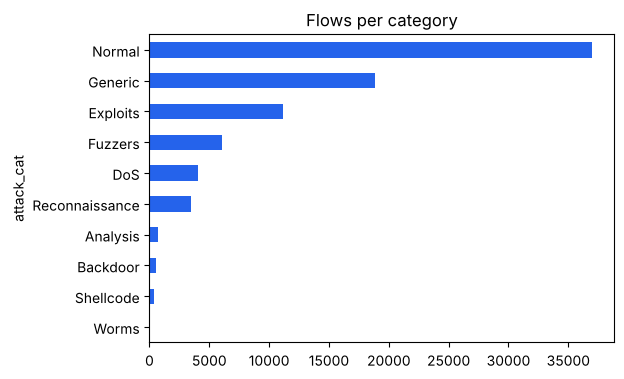

In [2]:
print(df['label'].value_counts().rename({0: 'Normal', 1: 'Attack'}))
df['attack_cat'].value_counts().plot.barh(figsize=(6, 4), title='Flows per category', color='#2563eb')
plt.gca().invert_yaxis(); plt.show()

The categories are heavily imbalanced: Worms has only 44 rows, while Normal has 37,000. Expect rare classes to be hard.

## 2. The leakage trap
The original version of this project reported **100% accuracy**. That came from feeding `attack_cat` (and `id`) into the model as features. `attack_cat == 'Normal'` *is* the label, and `id` is ordered by class, so the model memorises the answer instead of learning traffic patterns.

In [3]:
CATEGORICAL = ['proto', 'service', 'state']

def make_model(cat_cols, trees=100):
    # One-hot encodes the categorical columns and trains a Random Forest
    pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='passthrough')
    return Pipeline([('prep', pre), ('rf', RandomForestClassifier(n_estimators=trees, n_jobs=-1, random_state=SEED))])

clean = [c for c in df.columns if c not in ('id', 'attack_cat', 'label')]
train_idx, test_idx = train_test_split(df.index, test_size=0.2, stratify=df['attack_cat'], random_state=SEED)
y_tr, y_te = df.loc[train_idx, 'label'], df.loc[test_idx, 'label']

for name, cols, cats in [('Leaky (with attack_cat)', clean + ['attack_cat'], CATEGORICAL + ['attack_cat']),
                         ('Leaky (with id)', clean + ['id'], CATEGORICAL),
                         ('Clean', clean, CATEGORICAL)]:
    m = make_model(cats).fit(df.loc[train_idx, cols], y_tr)
    print(f"{name:26s} accuracy = {accuracy_score(y_te, m.predict(df.loc[test_idx, cols])):.4f}")

Leaky (with attack_cat)    accuracy = 1.0000


Leaky (with id)            accuracy = 0.9982


Clean                      accuracy = 0.9766


Dropping both columns gives a realistic ~97-98% accuracy. Everything below uses the clean feature set.

## 3. Binary detection: normal vs attack

In [4]:
binary = make_model(CATEGORICAL, trees=300).fit(df.loc[train_idx, clean], y_tr)
pred = binary.predict(df.loc[test_idx, clean])
proba = binary.predict_proba(df.loc[test_idx, clean])[:, 1]
print(classification_report(y_te, pred, target_names=['Normal', 'Attack'], digits=3))
print(f'ROC-AUC: {roc_auc_score(y_te, proba):.4f}')

              precision    recall  f1-score   support

      Normal      0.967     0.980     0.974      7400
      Attack      0.984     0.973     0.978      9067

    accuracy                          0.976     16467
   macro avg      0.976     0.977     0.976     16467
weighted avg      0.976     0.976     0.976     16467

ROC-AUC: 0.9972


![Binary confusion matrix](../reports/figures/confusion_binary.png)

![Feature importance](../reports/figures/feature_importance.png)

Connection-count features (`ct_dst_src_ltm`, `ct_state_ttl`), bytes sent (`sbytes`) and time-to-live (`sttl`) carry the most signal.

## 4. Attack categorization (10 classes)

In [5]:
yc_tr, yc_te = df.loc[train_idx, 'attack_cat'], df.loc[test_idx, 'attack_cat']
multi = make_model(CATEGORICAL, trees=300).fit(df.loc[train_idx, clean], yc_tr)
cpred = multi.predict(df.loc[test_idx, clean])
print(classification_report(yc_te, cpred, digits=3, zero_division=0))
print(f"Macro F1: {f1_score(yc_te, cpred, average='macro'):.3f}")

                precision    recall  f1-score   support

      Analysis      1.000     0.074     0.138       135
      Backdoor      0.333     0.009     0.017       117
           DoS      0.390     0.361     0.375       818
      Exploits      0.634     0.731     0.679      2227
       Fuzzers      0.691     0.667     0.678      1212
       Generic      0.997     0.972     0.984      3774
        Normal      0.956     0.989     0.972      7400
Reconnaissance      0.912     0.758     0.828       699
     Shellcode      0.591     0.342     0.433        76
         Worms      0.000     0.000     0.000         9

      accuracy                          0.867     16467
     macro avg      0.650     0.490     0.510     16467
  weighted avg      0.866     0.867     0.861     16467

Macro F1: 0.510


![Multi-class confusion matrix](../reports/figures/confusion_multiclass.png)

Normal, Generic and Reconnaissance are recognised well. DoS, Analysis, Backdoor and Worms are mostly confused with **Exploits**, because their flow-level statistics look alike and they have few samples.

## 5. Takeaways and next steps
- Binary detection is strong (~97.6% accuracy, ~0.997 ROC-AUC) once leakage is removed.
- Rare attack categories need more work: class weighting, SMOTE oversampling, or gradient boosting (XGBoost / LightGBM).
- Evaluate on the second official UNSW-NB15 partition to test generalisation beyond a random split.